In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from __future__ import division, print_function, unicode_literals

import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd",category=FutureWarning)

SyntaxError: from __future__ imports must occur at the beginning of the file (<ipython-input-1-49e8d7242160>, line 12)

# Make notebook stable across runs

In [2]:
np.random.seed(42)

NameError: name 'np' is not defined

# Get the data

In [94]:
data = pd.read_csv('tema2.csv')

In [95]:
data

,SDA,SDE,VAR,HIPO,ANEMIE,AA,HDSI,GAS,GASHP,ESOFAGITA,ANO,BC,CEFALEE,CONS,DRE,ULCER,STOMUCFUND
0,NU,DA,NU,DA,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,HEMOR
1,NU,NU,NU,DA,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,N
2,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,N
3,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,ERITEM
4,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,NU,DA,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,N
495,NU,NU,NU,DA,NU,NU,NU,NU,NU,NU,DA,NU,NU,NU,NU,NU,N
496,NU,NU,NU,NU,NU,NU,NU,DA,NU,NU,DA,NU,NU,NU,NU,NU,N
497,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,N


In [96]:
data.shape

(499, 17)

In [97]:
data.head()

,SDA,SDE,VAR,HIPO,ANEMIE,AA,HDSI,GAS,GASHP,ESOFAGITA,ANO,BC,CEFALEE,CONS,DRE,ULCER,STOMUCFUND
0,NU,DA,NU,DA,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,HEMOR
1,NU,NU,NU,DA,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,N
2,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,N
3,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,ERITEM
4,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,N


In [98]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   SDA         499 non-null    object
 1   SDE         499 non-null    object
 2   VAR         499 non-null    object
 3   HIPO        499 non-null    object
 4   ANEMIE      499 non-null    object
 5   AA          499 non-null    object
 6   HDSI        499 non-null    object
 7   GAS         499 non-null    object
 8   GASHP       499 non-null    object
 9   ESOFAGITA   499 non-null    object
 10  ANO         499 non-null    object
 11  BC          499 non-null    object
 12  CEFALEE     499 non-null    object
 13  CONS        499 non-null    object
 14  DRE         499 non-null    object
 15  ULCER       499 non-null    object
 16  STOMUCFUND  499 non-null    object
dtypes: object(17)
memory usage: 66.4+ KB


In [99]:
data.describe()

,SDA,SDE,VAR,HIPO,ANEMIE,AA,HDSI,GAS,GASHP,ESOFAGITA,ANO,BC,CEFALEE,CONS,DRE,ULCER,STOMUCFUND
count,499,499,499,499,499,499,499,499,499,499,499,499,499,499,499,499,499
unique,2,2,2,2,2,2,3,2,2,2,2,2,2,2,2,3,7
top,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,NU,N
freq,382,425,470,371,486,495,487,436,425,475,484,490,491,488,487,494,449


In [5]:
# Scoatem valorile nule din setul de date
print(data.isna().sum())
data = data.dropna(subset = ['STOMUCFUND'])
print(f'\n{data.isna().sum()}')

NameError: name 'data' is not defined

In [6]:
print(data.dtypes)

from sklearn.preprocessing import LabelEncoder
labelEncoder = LabelEncoder()

for column in data.columns:
    data[column] = labelEncoder.fit_transform(data[column].values)

print(f'\n{data.dtypes}')

data.head()

NameError: name 'data' is not defined

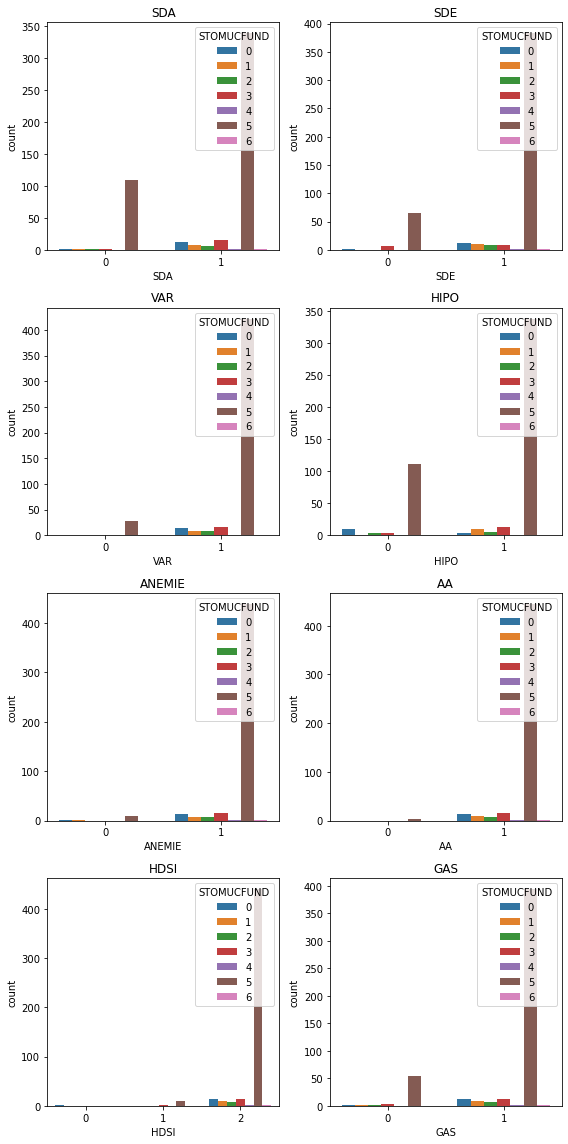

In [102]:
#Facem grafice pentru fiecare simptom
cols = []
for col in data.columns:
    cols.append(col)
cols.pop()

n_rows = 4
n_cols = 2

fig, axis = plt.subplots(n_rows, n_cols, figsize = (n_cols * 4, n_rows * 4))

for r in range(0, n_rows):
    for c in range(0, n_cols):
        i = r * n_cols + c
        ax = axis[r][c]
        sns.countplot(data[cols[i]], hue = data['STOMUCFUND'], ax=ax)
        ax.set_title(cols[i])
        ax.legend(title = 'STOMUCFUND', loc = 'upper right')
plt.tight_layout()

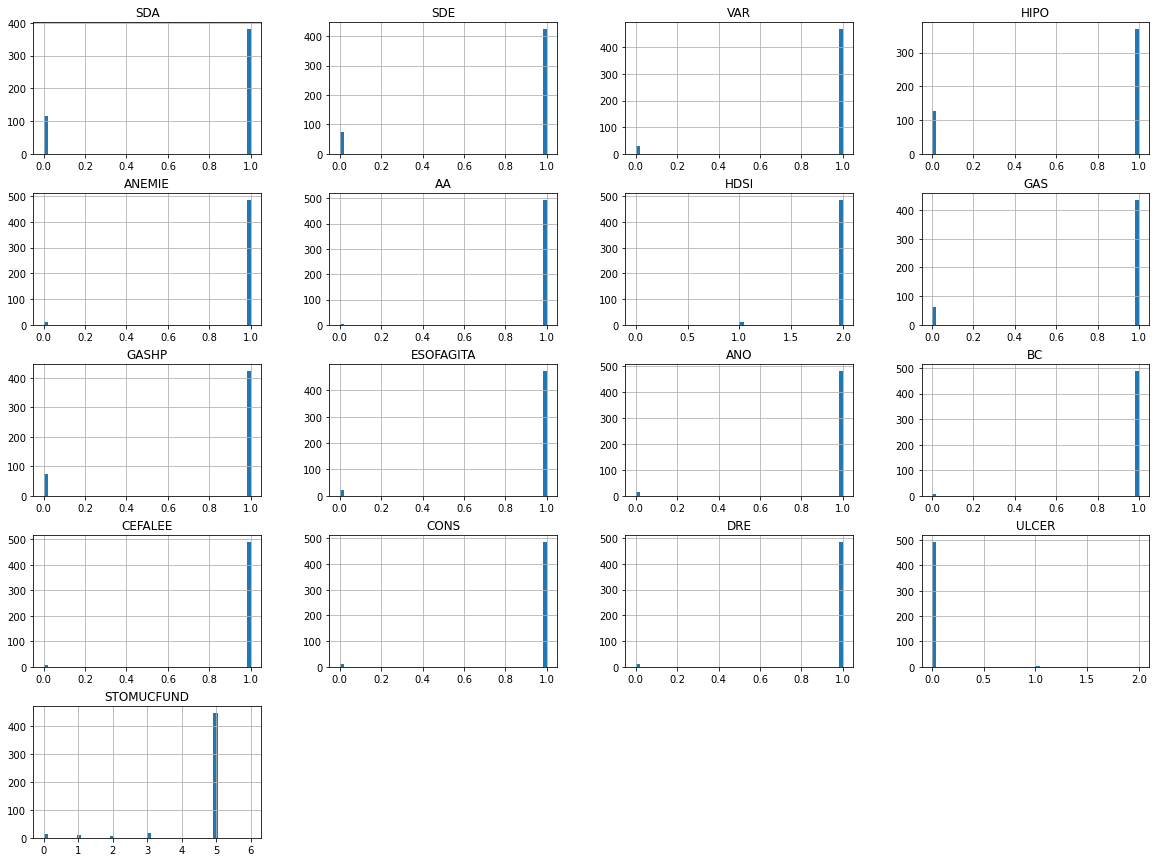

In [103]:
%matplotlib inline
data.hist(bins=50, figsize=(20,15))
plt.show()

In [104]:
SDA = data.groupby('SDA')['STOMUCFUND'].value_counts() / data.groupby('SDA')['STOMUCFUND'].count()

SDE = data.groupby('SDE')['STOMUCFUND'].value_counts() / data.groupby('SDE')['STOMUCFUND'].count()

VAR = data.groupby('VAR')['STOMUCFUND'].value_counts() / data.groupby('VAR')['STOMUCFUND'].count()

HIPO = data.groupby('HIPO')['STOMUCFUND'].value_counts() / data.groupby('HIPO')['STOMUCFUND'].count()

ANEMIE = data.groupby('ANEMIE')['STOMUCFUND'].value_counts() / data.groupby('ANEMIE')['STOMUCFUND'].count()

AA = data.groupby('AA')['STOMUCFUND'].value_counts() / data.groupby('AA')['STOMUCFUND'].count()

HDSI = data.groupby('HDSI')['STOMUCFUND'].value_counts() / data.groupby('HDSI')['STOMUCFUND'].count()

GAS = data.groupby('GAS')['STOMUCFUND'].value_counts() / data.groupby('GAS')['STOMUCFUND'].count()

GASHP = data.groupby('GASHP')['STOMUCFUND'].value_counts() / data.groupby('GASHP')['STOMUCFUND'].count()

ESOFAGITA = data.groupby('ESOFAGITA')['STOMUCFUND'].value_counts() / data.groupby('ESOFAGITA')['STOMUCFUND'].count()

ANO = data.groupby('ANO')['STOMUCFUND'].value_counts() / data.groupby('ANO')['STOMUCFUND'].count()

BC = data.groupby('BC')['STOMUCFUND'].value_counts() / data.groupby('BC')['STOMUCFUND'].count()

CEFALEE = data.groupby('CEFALEE')['STOMUCFUND'].value_counts() / data.groupby('CEFALEE')['STOMUCFUND'].count()

CONS = data.groupby('CONS')['STOMUCFUND'].value_counts() / data.groupby('CONS')['STOMUCFUND'].count()

DRE = data.groupby('DRE')['STOMUCFUND'].value_counts() / data.groupby('DRE')['STOMUCFUND'].count()

ULCER = data.groupby('ULCER')['STOMUCFUND'].value_counts() / data.groupby('ULCER')['STOMUCFUND'].count()


print(SDA)
print(SDE)
print(VAR)
print(HIPO)
print(ANEMIE)
print(AA)
print(HDSI)
print(GAS)
print(GASHP)
print(ESOFAGITA)
print(ANO)
print(BC)
print(CEFALEE)
print(CONS)
print(DRE)
print(ULCER)

SDA  STOMUCFUND
0    5             0.940171
     0             0.017094
     1             0.017094
     2             0.017094
     3             0.008547
1    5             0.887435
     3             0.039267
     0             0.031414
     1             0.020942
     2             0.015707
     4             0.002618
     6             0.002618
Name: STOMUCFUND, dtype: float64
SDE  STOMUCFUND
0    5             0.891892
     3             0.094595
     0             0.013514
1    5             0.901176
     0             0.030588
     1             0.023529
     3             0.021176
     2             0.018824
     4             0.002353
     6             0.002353
Name: STOMUCFUND, dtype: float64
VAR  STOMUCFUND
0    5             0.931034
     1             0.034483
     3             0.034483
1    5             0.897872
     3             0.031915
     0             0.029787
     1             0.019149
     2             0.017021
     4             0.002128
     6            

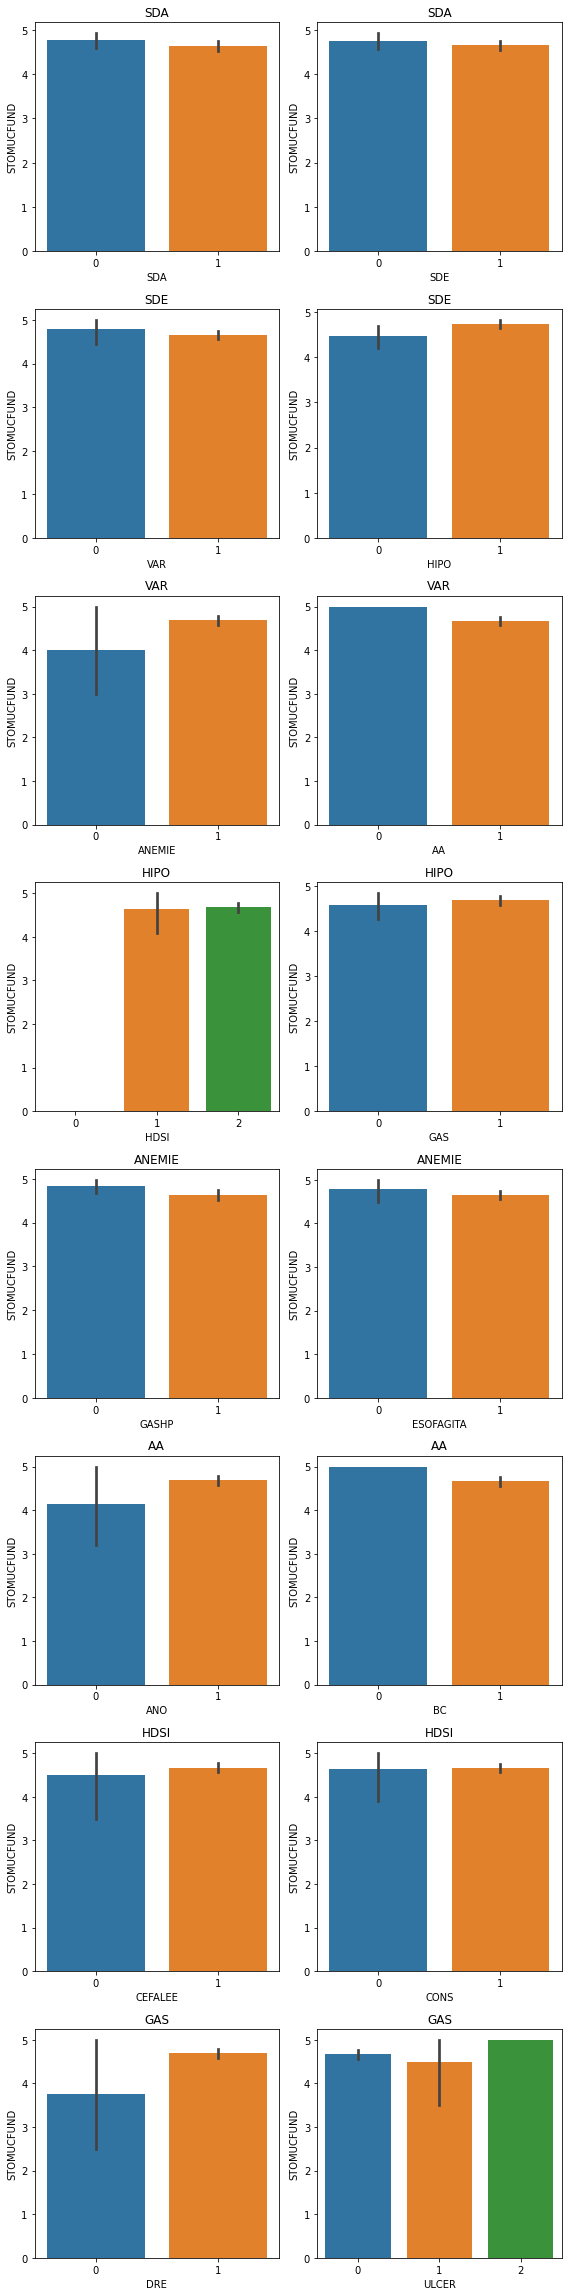

In [105]:
n_rows = 8
n_cols = 2

cols = []
for i in range(0, len(data.columns) - 1):
    cols.append(data.columns[i])

fig, axis = plt.subplots(n_rows, n_cols, figsize = (n_cols * 4, n_rows * 4))

for i in range(0, n_rows):
    for j in range(0, n_cols):
        index = i * n_cols + j
        ax = axis[i][j]
        sns.barplot(x = cols[index], y = 'STOMUCFUND', data = data, ax=ax)
        ax.set_title(cols[i])
plt.tight_layout()
    

In [106]:
x = data.iloc[:, 0:len(data.columns) - 1].values
y = data['STOMUCFUND'].values

print(x)
print(y)

[[1 0 1 ... 1 1 0]
 [1 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 0]
 ...
 [1 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 0]
 [1 0 1 ... 1 1 0]]
[3 5 5 1 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 3 3 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 3 5 5 5 0
 5 5 5 5 5 5 5 1 5 1 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 1 5 2 5 5 5 5 5 5 5 1
 5 5 5 5 0 5 5 5 5 5 5 5 5 5 5 1 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 0 0 5 5 5 2 5 5 5 2 5 5 5 5 5 5 5 5 5 5 5 3 5 0 5 5 5 5 2
 5 5 5 3 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 0 5 5 5 5 2 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 0 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 3 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 3 5 5
 5 5 5 5 5 5 3 5 0 5 5 5 5 5 5 5 5 5 5 1 5 5 3 0 5 5 5 5 5 5 5 3 5 5 5 5 5
 5 5 5 5 5 5 3 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 0 5 5 5 5 0 5
 5 1 5 5 5 5 2 5 5 5 5 5 5 2 5 0 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 2 5 3 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 

In [107]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [108]:
def models(x_train, y_train):
    from sklearn.tree import DecisionTreeClassifier
    tree = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
    tree.fit(x_train, y_train)
    
    print(f'Accuracy = {tree.score(x_train, y_train)}')
    
    return tree


In [90]:
model = models(x_train, y_train)

print(model)

Accuracy = 0.9147869674185464
DecisionTreeClassifier(criterion='entropy', random_state=0)


In [91]:
feature_importance = pd.DataFrame({'feature': data.iloc[:, 0:len(data.columns) - 1].columns, 'importance': model.feature_importances_})
feature_importance = feature_importance.sort_values('importance', ascending = False).set_index('feature')
print(feature_importance)

           importance
feature              
SDA          0.121470
HDSI         0.119397
SDE          0.102215
HIPO         0.096587
VAR          0.086221
GAS          0.081344
ANO          0.074638
DRE          0.073388
GASHP        0.058533
ESOFAGITA    0.049947
CONS         0.044554
ULCER        0.039252
ANEMIE       0.038990
AA           0.006147
BC           0.005427
CEFALEE      0.001889
